titles:  ['', 'squares']
xlabels: ['', 'x']
current Axes is axes[1]: True


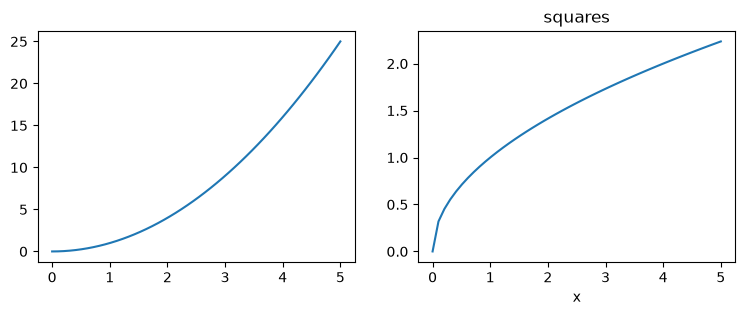

In [1]:
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(0, 5, 50)
# WRONG: pyplot's state machine acts on whichever Axes is "current"
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(x, x**2)
axes[1].plot(x, np.sqrt(x))
plt.title("squares") # meant for the left panel
plt.xlabel("x") # meant for both
print("titles: ", [ax.get_title() for ax in axes])
print("xlabels:", [ax.get_xlabel() for ax in axes])
print("current Axes is axes[1]:", plt.gca() is axes[1])
# titles: ['', 'squares']
# xlabels: ['', 'x']
# current Axes is axes[1]: True

titles:  ['squares', 'square roots']
xlabels: ['x', 'x']


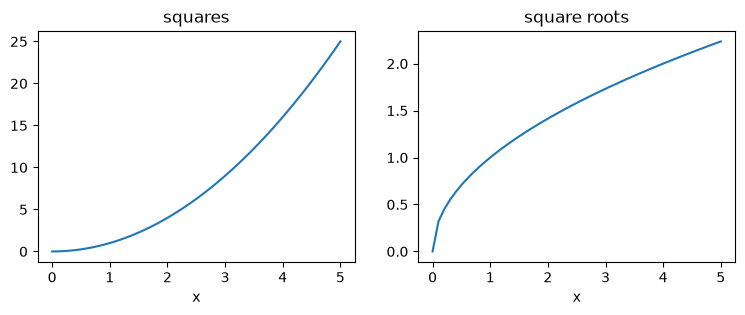

In [3]:
# RIGHT: name the Axes you mean
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(x, x**2)
axes[1].plot(x, np.sqrt(x))
axes[0].set_title("squares")
axes[1].set_title("square roots")
for ax in axes:
    ax.set_xlabel("x")
print("titles: ", [ax.get_title() for ax in axes])
print("xlabels:", [ax.get_xlabel() for ax in axes])
# titles: ['squares', 'square roots']
# xlabels: ['x', 'x']

        count   mean  median   std
time                              
Lunch      68  17.17   15.96  7.71
Dinner    176  20.80   18.39  9.14
skew of total_bill: 1.133


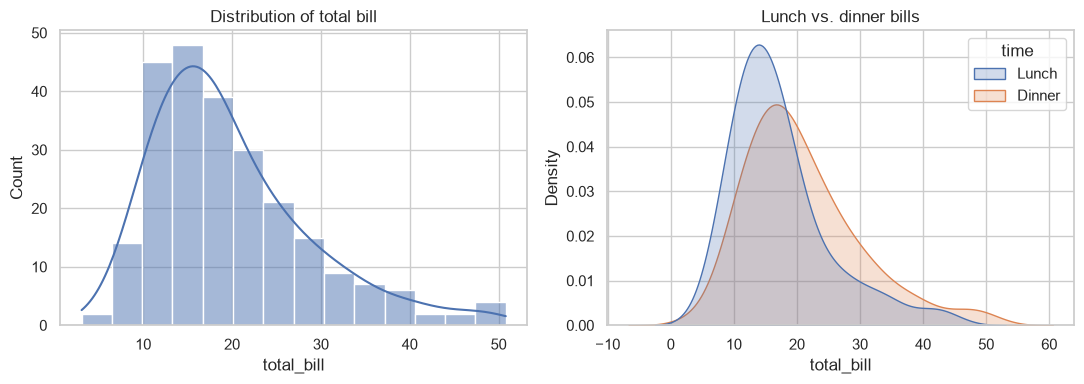

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
tips = sns.load_dataset("tips")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=tips, x="total_bill", kde=True, ax=axes[0])
axes[0].set_title("Distribution of total bill")
sns.kdeplot(data=tips, x="total_bill", hue="time", fill=True,
common_norm=False, ax=axes[1])
axes[1].set_title("Lunch vs. dinner bills")
fig.tight_layout()
print(tips.groupby("time", observed=True)["total_bill"]
.agg(["count", "mean", "median", "std"]).round(2))
print("skew of total_bill:", round(tips["total_bill"].skew(), 3))
# count mean median std
# time
# Lunch 68 17.17 15.96 7.71
# Dinner 176 20.80 18.39 9.14
# skew of total_bill: 1.133

            total_bill    tip   size
total_bill       1.000  0.676  0.598
tip              0.676  1.000  0.489
size             0.598  0.489  1.000


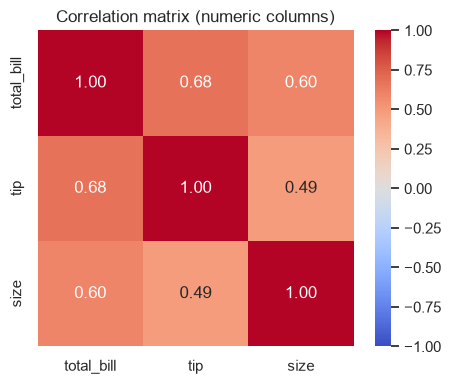

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="white")
tips = sns.load_dataset("tips")
corr = tips.select_dtypes("number").corr()
print(corr.round(3))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation matrix (numeric columns)")
fig.tight_layout()
# total_bill tip size
# total_bill 1.000 0.676 0.598
# tip 0.676 1.000 0.489
# size 0.598 0.489 1.000

In [8]:
import pandas as pd
import seaborn as sns
df = sns.load_dataset("titanic")
print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")
print(df.dtypes.astype(str).value_counts().to_string())
print(f"memory: {df.memory_usage(deep=True).sum() / 1024:.0f} KiB")
print(f"fully duplicated rows: {df.duplicated().sum()}")
sizes = df.groupby(list(df.columns), dropna=False, observed=True).size()
print(f"largest identical group: {sizes.max()} rows")
# rows: 891, columns: 15
# str 5
# int64 4
# float64 2
# category 2
# bool 2
# memory: 100 KiB
# fully duplicated rows: 107
# largest identical group: 13 rows

rows: 891, columns: 15
str         5
int64       4
float64     2
category    2
bool        2
memory: 100 KiB
fully duplicated rows: 107
largest identical group: 13 rows


In [9]:
missing = pd.DataFrame({"n_missing": df.isna().sum(),
"share": df.isna().mean().round(3)})
print(missing[missing["n_missing"] > 0].to_string())
flags = df.assign(deck_na=df["deck"].isna(), age_na=df["age"].isna())
print(flags.groupby("class", observed=True)[["deck_na", "age_na"]]
.mean().round(3).to_string())
print(flags.groupby("age_na")["survived"].agg(["mean", "size"])
.round(3).to_string())
# n_missing share
# age 177 0.199
# embarked 2 0.002
# deck 688 0.772
# embark_town 2 0.002
# deck_na age_na
# class
# First 0.190 0.139
# Second 0.913 0.060
# Third 0.976 0.277
# mean size
# age_na
# False 0.406 714
# True 0.294 177

             n_missing  share
age                177  0.199
embarked             2  0.002
deck               688  0.772
embark_town          2  0.002
        deck_na  age_na
class                  
First     0.190   0.139
Second    0.913   0.060
Third     0.976   0.277
         mean  size
age_na             
False   0.406   714
True    0.294   177


In [10]:
print(df["survived"].value_counts().sort_index().to_string())
print(f"positive rate: {df['survived'].mean():.3f}")
# survived
# 0 549
# 1 342
# positive rate: 0.384

survived
0    549
1    342
positive rate: 0.384


In [11]:
print(df[["age", "fare"]].describe().round(2).to_string())
print(f"age skew: {df['age'].skew():.2f}")
print(f"fare skew: {df['fare'].skew():.2f}")
# age fare
# count 714.00 891.00
# mean 29.70 32.20
# std 14.53 49.69
# min 0.42 0.00
# 25% 20.12 7.91
# 50% 28.00 14.45
# 75% 38.00 31.00
# max 80.00 512.33
# age skew: 0.39
# fare skew: 4.79

          age    fare
count  714.00  891.00
mean    29.70   32.20
std     14.53   49.69
min      0.42    0.00
25%     20.12    7.91
50%     28.00   14.45
75%     38.00   31.00
max     80.00  512.33
age skew: 0.39
fare skew: 4.79


In [12]:
num = df[["survived", "pclass", "age", "sibsp", "parch", "fare"]]
print(num.corr().round(3).to_string())
# survived pclass age sibsp parch fare
# survived 1.000 -0.338 -0.077 -0.035 0.082 0.257
# pclass -0.338 1.000 -0.369 0.083 0.018 -0.549
# age -0.077 -0.369 1.000 -0.308 -0.189 0.096
# sibsp -0.035 0.083 -0.308 1.000 0.415 0.160
# parch 0.082 0.018 -0.189 0.415 1.000 0.216
# fare 0.257 -0.549 0.096 0.160 0.216 1.000

          survived  pclass    age  sibsp  parch   fare
survived     1.000  -0.338 -0.077 -0.035  0.082  0.257
pclass      -0.338   1.000 -0.369  0.083  0.018 -0.549
age         -0.077  -0.369  1.000 -0.308 -0.189  0.096
sibsp       -0.035   0.083 -0.308  1.000  0.415  0.160
parch        0.082   0.018 -0.189  0.415  1.000  0.216
fare         0.257  -0.549  0.096  0.160  0.216  1.000


In [13]:
rates = df.pivot_table(index="sex", columns="class", values="survived",
aggfunc="mean", observed=True)
sizes = df.pivot_table(index="sex", columns="class", values="survived",
aggfunc="size", observed=True)
print(rates.round(3).to_string())
print(sizes.to_string())
# class First Second Third
# sex
# female 0.968 0.921 0.500
# male 0.369 0.157 0.135
# class First Second Third
# sex
# female 94 76 144
# male 122 108 347

class   First  Second  Third
sex                         
female  0.968   0.921  0.500
male    0.369   0.157  0.135
class   First  Second  Third
sex                         
female     94      76    144
male      122     108    347


In [14]:
print(df.groupby("alone")["survived"].mean().round(3).to_string())
print(df.pivot_table(index="alone", columns="sex", values="survived",
aggfunc="mean").round(3).to_string())
# alone
# False 0.506
# True 0.304
# sex female male
# alone
# False 0.713 0.271
# True 0.786 0.156

alone
False    0.506
True     0.304
sex    female   male
alone               
False   0.713  0.271
True    0.786  0.156


In [15]:
print(f"fare == 0: {(df['fare'] == 0).sum()} passengers")
zeros = df.loc[df["fare"] == 0]
print(f" all male: {(zeros['sex'] == 'male').all()}")
print(f" one port only: {zeros['embark_town'].nunique() == 1}"
f" ({zeros['embark_town'].iloc[0]})")
print(f" survival rate: {zeros['survived'].mean():.3f}")
print(f"fare >= 500: {(df['fare'] >= 500).sum()} passengers, all at "
f"{df.loc[df['fare'] >= 500, 'fare'].iloc[0]:.4f}")
ages = df["age"].dropna()
print(f"youngest age recorded: {ages.min():.2f}")
print(f"ages with a fractional part: {(ages % 1 != 0).sum()}")
print(f" of those, exactly .5: {(ages % 1 == 0.5).sum()}")
# fare == 0: 15 passengers
# all male: True
# one port only: True (Southampton)
# survival rate: 0.067
# fare >= 500: 3 passengers, all at 512.3292
# youngest age recorded: 0.42
# ages with a fractional part: 25
# of those, exactly .5: 18

fare == 0: 15 passengers
 all male: True
 one port only: True (Southampton)
 survival rate: 0.067
fare >= 500: 3 passengers, all at 512.3292
youngest age recorded: 0.42
ages with a fractional part: 25
 of those, exactly .5: 18


In [16]:
print(pd.crosstab(df["alive"], df["survived"]).to_string())
print("agreement: "
f"{((df['alive'] == 'yes').astype(int) == df['survived']).mean():.3f}")
# survived 0 1
# alive
# no 549 0
# yes 0 342
# agreement: 1.000

survived    0    1
alive             
no        549    0
yes         0  342
agreement: 1.000


In [18]:
sub = df.dropna(subset=["age"])
print(f"pooled corr(age, fare): {sub['age'].corr(sub['fare']):+.3f}" f" (n = {len(sub)})")
for name, g in sub.groupby("class", observed=True):
    print(f" {name:<7} n = {len(g):>3}" f" corr = {g['age'].corr(g['fare']):+.3f}" f" mean age = {g['age'].mean():.1f}" f" mean fare = {g['fare'].mean():.2f}")
# pooled corr(age, fare): +0.096 (n = 714)
# First n = 186 corr = -0.219 mean age = 38.2 mean fare = 87.96
# Second n = 173 corr = -0.197 mean age = 29.9 mean fare = 21.47
# Third n = 355 corr = -0.260 mean age = 25.1 mean fare = 13.23

pooled corr(age, fare): +0.096 (n = 714)
 First   n = 186 corr = -0.219 mean age = 38.2 mean fare = 87.96
 Second  n = 173 corr = -0.197 mean age = 29.9 mean fare = 21.47
 Third   n = 355 corr = -0.260 mean age = 25.1 mean fare = 13.23


6000 points -> 600 drawn in the third panel


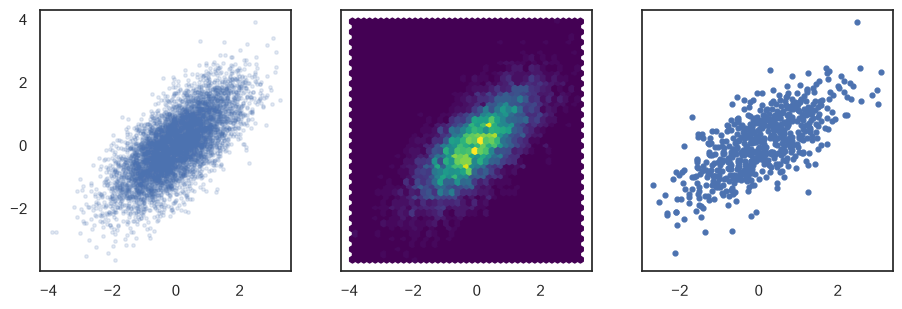

In [19]:
import matplotlib.pyplot as plt
import numpy as np
rng = np.random.default_rng(0)
x = rng.normal(size=6000)
y = 0.7 * x + rng.normal(scale=0.7, size=6000)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
axes[0].scatter(x, y, s=6, alpha=0.15) # 1. shrink and fade
axes[1].hexbin(x, y, gridsize=40, cmap="viridis") # 2. bin, colour by count
idx = rng.choice(len(x), 600, replace=False) # 3. subsample, and say so
axes[2].scatter(x[idx], y[idx], s=12)
print(len(x), "points ->", len(idx), "drawn in the third panel")
# 6000 points -> 600 drawn in the third panel

In [24]:
rng = np.random.default_rng(0)
y = df["survived"].to_numpy(dtype=float)
n = len(y)
held = rng.permutation(n) < n // 4 # a held-out quarter, fixed once
def abs_corr(cols, rows):
    """|correlation| of each column with survived, computed on the given rows."""
    x = cols[rows]
    x = (x - x.mean(axis=0)) / x.std(axis=0)
    t = (y[rows] - y[rows].mean()) / y[rows].std()
    return np.abs(x.T @ t) / len(t)
picks = {"all rows": np.ones(n, bool), "training rows only": ~held}
scores = {label: [] for label in picks}
for _ in range(200):
    noise = rng.normal(size=(n, 100)) # 100 columns of pure noise
for label, rows in picks.items():
    best = abs_corr(noise, rows).argmax()
    scores[label].append(abs_corr(noise[:, [best]], held)[0])
for label, s in scores.items():
    print(f"winner screened on {label + ':':<20} {np.mean(s):.3f} on the held-out quarter")
print(f"a single noise column, no screening: {abs_corr(rng.normal(size=(n, 2000)), held).mean():.3f}")
# winner screened on all rows: 0.097 on the held-out quarter
# winner screened on training rows only: 0.054 on the held-out quarter
# a single noise column, no screening: 0.053

winner screened on all rows:            0.150 on the held-out quarter
winner screened on training rows only:  0.023 on the held-out quarter
a single noise column, no screening: 0.053


Key idea. Each exercise runs one step of the procedure to its conclusion on data you have not been shown the
answers for.
Run steps 1 through 4 on sns.load_dataset("penguins") , then write the unit-of-observation sentence and the missingness summary. 
Which column's missingness concentrates in one group?
Correlate the penguins' bill length with bill depth pooled and then within each species. Report all four numbers and explain the sign change from the species means.
Make a box plot and a violin plot of body_mass_g by species side by side, then repeat with hue="sex" . 
Name one feature the violin shows that the box hides. 
Turn the right-hand column of the findings table into an ordered preprocessing plan: what is dropped, imputed, transformed, and in what order.